In [27]:
import numpy as np

# Define A exactly
A = np.array([
    [3, 2,  2],
    [2, 3, -2]
], dtype=float)

# Define full V (3x3) exactly as in the image
V = np.array([
    [1/np.sqrt(2),   1/np.sqrt(2),   0],
    [1/np.sqrt(18), -1/np.sqrt(18),  4/np.sqrt(18)],
    [2/3,           -2/3,            1/3]
], dtype=float)

# Singular values
sigma = np.array([5, 3])

# Take first two right singular vectors
V_reduced = V[:, :2]

# Compute U using u = Av / sigma
U_computed = (A @ V_reduced) / sigma

print("Computed U =")
print(U_computed)


Computed U =
[[0.78521164 0.1055275 ]
 [0.1575974  0.6801467 ]]


In [30]:
print(U_computed @ np.diag([5,3]) @ V[:,:2].T)


[[ 3.          0.85076158  2.40631714]
 [ 2.         -0.29520603 -0.83496874]]


In [4]:
1/2**0.5

0.7071067811865475

In [2]:
import numpy as np
import torch

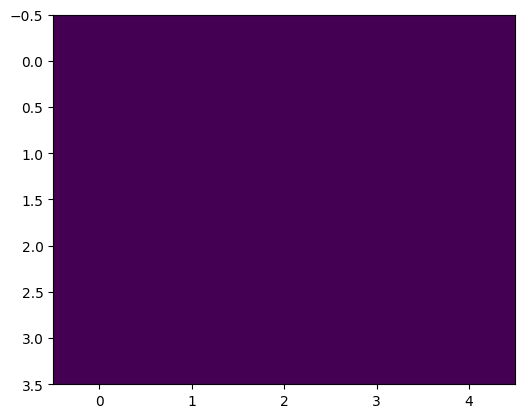

In [5]:
img = np.zeros((4, 5))
import matplotlib.pyplot as plt
plt.imshow(img)

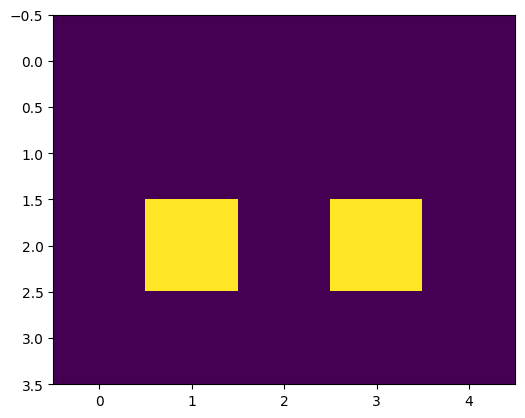

In [7]:
img[[2, 2], [1, 3]] = 1
plt.imshow(img)

In [10]:
import torch
img = torch.tensor(img)
threshold = 0.1
mask = img > threshold


In [11]:
coords = torch.nonzero(mask, as_tuple=False)


In [12]:
feats = img[mask].unsqueeze(1)


In [13]:
batch = torch.zeros(coords.shape[0], 1, dtype=torch.int)
coords = torch.cat([batch, coords], dim=1)


In [17]:
# =========================
# PyTorch: Sparse Conv2D with IMAGE as input
# =========================
import torch

def sparse_conv2d_torch_image(image, weights, kernel_size):
    """
    image: (H, W, Cin) tensor
    weights: (k, k, Cin, Cout) tensor
    """
    H, W, Cin = image.shape
    k = kernel_size
    r = k // 2

    coords = []
    feats = []
    for i in range(H):
        for j in range(W):
            if not torch.all(image[i, j] == 0):
                coords.append((i, j))
                feats.append(image[i, j])

    coords = torch.tensor(coords, device=image.device)
    feats = torch.stack(feats)

    coord_to_index = {tuple(c.tolist()): i for i, c in enumerate(coords)}
    out = {}

    for idx, (x, y) in enumerate(coords):
        x, y = int(x), int(y)
        for dx in range(-r, r + 1):
            for dy in range(-r, r + 1):
                nx, ny = x + dx, y + dy
                if (nx, ny) in coord_to_index:
                    j = coord_to_index[(nx, ny)]
                    contrib = feats[j] @ weights[dx+r, dy+r]
                    out[(x, y)] = out.get((x, y), 0) + contrib

    out_image = torch.zeros((H, W, weights.shape[-1]), device=image.device)
    for (x, y), val in out.items():
        out_image[x, y] = val

    return out_image
weights = torch.randn(3, 3, 1, 2)  # (k, k, Cin, Cout)
out_image = sparse_conv2d_torch_image(img.unsqueeze(-1).float(), weights, kernel_size=3)

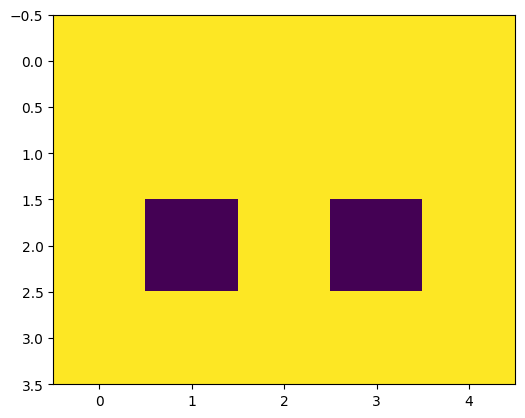

In [19]:
plt.imshow(out_image[..., 0].numpy())  # Visualize first output channel

In [1]:
import numpy as np

def voxelize_point_cloud(points, voxel_size, coord_range):
    """
    points: (N, 3) numpy array -> [x, y, z]
    voxel_size: (vx, vy, vz)
    coord_range: (xmin, ymin, zmin, xmax, ymax, zmax)
    """

    vx, vy, vz = voxel_size
    xmin, ymin, zmin, xmax, ymax, zmax = coord_range

    # 1. Clip points to range
    mask = (
        (points[:, 0] >= xmin) & (points[:, 0] < xmax) &
        (points[:, 1] >= ymin) & (points[:, 1] < ymax) &
        (points[:, 2] >= zmin) & (points[:, 2] < zmax)
    )
    points = points[mask]

    # 2. Compute voxel indices
    indices = np.floor(
        (points - np.array([xmin, ymin, zmin])) /
        np.array([vx, vy, vz])
    ).astype(np.int32)

    # 3. Use unique voxels (occupancy)
    voxels = np.unique(indices, axis=0)

    return voxels


# Example
points = np.random.rand(1000, 3) * 10        # random point cloud
voxel_size = (0.5, 0.5, 0.5)
coord_range = (0, 0, 0, 10, 10, 10)

voxels = voxelize_point_cloud(points, voxel_size, coord_range)
print(voxels.shape)   # (num_voxels, 3)


(942, 3)


In [1]:
import sys
sys.path.append('./..')


In [2]:
from utils.data_loader import get_LiDAR

In [3]:
lidar = get_LiDAR(count=1)

In [4]:
lidar[0].shape

(16000, 4)

In [5]:
import open3d as o3d
pcd  = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(lidar[0][:, :3])
o3d.visualization.draw_geometries([pcd])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [8]:
import sys 
sys.path.append('./..')
from utils.data_loader import get_LiDAR, get_radar

lidar = get_LiDAR(count=1)[0]
radar = get_radar(count=1)[0]
print(lidar.shape)
print(radar.shape)

F:\Work\DeepLearning\Research\V2X-Radar-V\training\velodyne
F:\Work\DeepLearning\Research\V2X-Radar-V\training\velodyne\000000.bin
F:\Work\DeepLearning\Research\V2X-Radar-V\training\radar\000000.bin
(127501, 3)
(9027, 5)


In [5]:
import torch 
lidar = torch.tensor(lidar)
radar = torch.tensor(radar)

In [9]:
min_l = lidar.min(axis= 0)

In [10]:
min_l

array([-191.70665 ,  -97.6813  ,  -13.835814], dtype=float32)

In [7]:
min_l

torch.return_types.min(
values=tensor([-191.7066,  -97.6813,  -13.8358]),
indices=tensor([ 30087, 114654,  91788]))

In [2]:
import open3d as o3d
pcd_lidar  = o3d.geometry.PointCloud()
pcd_lidar.points = o3d.utility.Vector3dVector(lidar[:, :3])
o3d.visualization.draw_geometries([pcd_lidar])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:

pcd_radar  = o3d.geometry.PointCloud()
pcd_radar.points = o3d.utility.Vector3dVector(radar[:, :3])
o3d.visualization.draw_geometries([pcd_radar])